# General EMA Analysis

Analyzes the general_ema.csv file in two sections:
- Target variable understanding - instrument distributions,
  internal consistency, cross-instrument correlations, per-student variance
- Label definition feasibility - weekly survey density,
  intra-week variance, observation gaps, composite score simulation

Outputs:
- outputs/reports/eda_general_ema_report.md
- outputs/figures/general_score_distributions.png
- outputs/figures/general_cross_instrument_correlation.png
- outputs/figures/general_per_student_variance.png
- outputs/figures/general_composite_score_simulation.png

Functions used in this notebook are later defined in src/data/loaders.py, src/labels/composite_score.py, and src/utils/time_utils.py.

In [20]:
from pathlib import Path
 
import pandas as pd
import numpy as np

In [21]:
PHQ4_ITEMS   = ["phq4-1", "phq4-2", "phq4-3", "phq4-4"]
SSE3_ITEMS   = ["sse3-1", "sse3-2", "sse3-3", "sse3-4"]
SCORE_COLS   = ["phq4_score", "pam", "stress", "social_level"]
TIMING_COLS  = ["phq4_resp_mean", "phq4_resp_median",
                "sse3_resp_mean",  "sse3_resp_median",
                "avg_ema_spent_time"]
ALL_EMA_COLS = PHQ4_ITEMS + SSE3_ITEMS + SCORE_COLS + TIMING_COLS

In [22]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Parse the YYYYMMDD date column into proper dates
    df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
    # ISO week label  →  "YYYY-Www"  (consistent across year boundaries)
    df["year_week"] = df["date"].dt.isocalendar().year.astype(str) + "-W" + \
                      df["date"].dt.isocalendar().week.astype(str).str.zfill(2)
    return df

In [23]:
# Whole table analysis of temporal coverage, survey counts, and missing data patterns

# Global and per-student date range
def temporal_coverage(df: pd.DataFrame) -> dict:
    global_min = df["date"].min()
    global_max = df["date"].max()
    total_days = (global_max - global_min).days + 1
    total_weeks = total_days / 7
 
    per_student = (
        df.groupby("uid")["date"]
        .agg(start="min", end="max")
        .assign(span_days=lambda x: (x["end"] - x["start"]).dt.days + 1)
    )
 
    return {
        "global_start":       global_min.date(),
        "global_end":         global_max.date(),
        "total_calendar_days": total_days,
        "total_calendar_weeks": round(total_weeks, 2),
        "n_students":         df["uid"].nunique(),
        "per_student":        per_student,
    }
 
# Weekly survey counts per student
def weekly_survey_counts(df: pd.DataFrame) -> pd.DataFrame:
    ema_present = ALL_EMA_COLS  # columns that actually exist in the file
    existing    = [c for c in ema_present if c in df.columns]
 
    df = df.copy()
    df["has_response"] = df[existing].notna().any(axis=1)
 
    weekly = (
        df[df["has_response"]]
        .groupby(["uid", "year_week"])
        .size()
        .reset_index(name="surveys_in_week")
    )
    return weekly

# Total survey counts per student
def per_student_survey_counts(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in ALL_EMA_COLS if c in df.columns]

    counts = (
        df[df[existing].notna().any(axis=1)]
        .groupby("uid")
        .size()
        .reset_index(name="total_surveys")
        .sort_values("total_surveys", ascending=False)
        .reset_index(drop=True)
    )
    return counts
 
# Missing value analysis per column
def missing_value_report(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in ALL_EMA_COLS if c in df.columns]
    total    = len(df)
 
    report = pd.DataFrame({
        "column":    existing,
        "missing_n": [df[c].isna().sum() for c in existing],
        "missing_%": [round(df[c].isna().mean() * 100, 2) for c in existing],
    })
    return report.sort_values("missing_%", ascending=False).reset_index(drop=True)

# Missing value analysis per student
def per_student_missing(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in ALL_EMA_COLS if c in df.columns]
    result = []
    for uid, grp in df.groupby("uid"):
        total      = len(grp)
        any_data   = grp[existing].notna().any(axis=1).sum()
        all_missing = total - any_data
        result.append({
            "uid":            uid,
            "total_rows":     total,
            "rows_with_data": any_data,
            "fully_missing":  all_missing,
            "pct_missing":    round(all_missing / total * 100, 2),
        })
    return pd.DataFrame(result).sort_values("pct_missing", ascending=False).reset_index(drop=True)
 
 
def print_section(title: str):
    print(f"\n{'═' * 60}")
    print(f"  {title}")
    print(f"{'═' * 60}")

In [24]:
def run_whole_table_analysis(path: str, save: bool = False):
    print(f"\n[EDA] Loading: {path}")
    df = load_data(path)
    print(f"      Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"      Students: {df['uid'].nunique()}")
 
    lines = [] 

    # Temporal coverage 
    print_section("Temporal Coverage")
    cov = temporal_coverage(df)
 
    print(f"  Global start (earliest survey)  : {cov['global_start']}")
    print(f"  Global end   (latest survey)    : {cov['global_end']}")
    print(f"  Total calendar days             : {cov['total_calendar_days']}")
    print(f"  Total calendar weeks            : {cov['total_calendar_weeks']}")
    print(f"  Number of students              : {cov['n_students']}")
 
    per = cov["per_student"]
    print(f"\n  Per-student span (days) — summary:")
    print(per["span_days"].describe().rename("span_days").to_string())
 
    print(f"\n  Earliest start dates (top 5 students):")
    print(per.nsmallest(5, "start")[["start","end","span_days"]].to_string())
 
    print(f"\n  Latest end dates (top 5 students):")
    print(per.nlargest(5, "end")[["start","end","span_days"]].to_string())
 
    lines += [
        "## Temporal Coverage\n",
        f"- **Global start**: {cov['global_start']}",
        f"- **Global end**: {cov['global_end']}",
        f"- **Calendar days**: {cov['total_calendar_days']}",
        f"- **Students**: {cov['n_students']}\n",
        "### Per-student span (days)\n",
        per["span_days"].describe().to_frame().to_markdown(), "\n",
    ]
 
    # Weekly survey counts 
    print_section("Weekly Survey Count Analysis")
    weekly = weekly_survey_counts(df)
 
    max_surveys_per_week = weekly["surveys_in_week"].max()
    mean_surveys         = weekly["surveys_in_week"].mean()
    dist                 = weekly["surveys_in_week"].value_counts().sort_index()
 
    print(f"  Max surveys a student received in a single week : {max_surveys_per_week}")
    print(f"  Mean surveys per (student, week)                : {mean_surveys:.2f}")
    print(f"\n  Distribution of surveys-per-week across all (student, week) pairs:")
    print(dist.rename_axis("surveys_in_week").reset_index(name="count").to_string(index=False))
 
    # Most survey-dense (student, week) pair
    busiest = weekly.loc[weekly["surveys_in_week"].idxmax()]
    print(f"\n  Most survey-dense (student, week): uid={busiest['uid']}, "
          f"week={busiest['year_week']}, surveys={busiest['surveys_in_week']}")
 
    lines += [
        "\n## Weekly Survey Counts\n",
        f"- **Max surveys in one week**: {max_surveys_per_week}",
        f"- **Mean surveys per (student, week)**: {mean_surveys:.2f}\n",
        "### Distribution of surveys per week\n",
        dist.rename_axis("surveys_in_week").reset_index(name="count").to_markdown(index=False), "\n",
    ]

    # Per-student survey counts 
    print_section("Total Surveys per Student")
    sc = per_student_survey_counts(df)
    print(sc.to_string(index=False))
    print(f"\n  Mean : {sc['total_surveys'].mean():.1f}")
    print(f"  Min  : {sc['total_surveys'].min()}")
    print(f"  Max  : {sc['total_surveys'].max()}")

    lines += [
        "\n## Total Surveys per Student\n",
        sc.to_markdown(index=False), "\n",
        f"\n**Mean surveys per student**: {sc['total_surveys'].mean():.1f}\n",
    ]
 
    # Missing-value report 
    print_section("Missing-Value Report (EMA columns)")
    mv = missing_value_report(df)
    print(mv.to_string(index=False))
 
    lines += [
        "\n## Missing Values per EMA Column\n",
        mv.to_markdown(index=False), "\n",
    ]
 
    # Per-student missing 
    print_section("Per-Student Missing-Value Summary")
    ps = per_student_missing(df)
    print(ps.to_string(index=False))
 
    # Students with >50% missing
    heavy = ps[ps["pct_missing"] > 50]
    print(f"\n  Students with >50 % fully-missing rows: {len(heavy)}")
    if not heavy.empty:
        print(heavy.to_string(index=False))
 
    lines += [
        "\n## Per-Student Missing Values\n",
        ps.to_markdown(index=False), "\n",
        f"\n**Students with >50% missing rows**: {len(heavy)}\n",
    ]
 
    # Save report 
    if save:
        out = Path("../../outputs/reports/eda_general_ema_report.md")
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_text("\n".join(lines), encoding="utf-8")
        print(f"\n[EDA] Report saved → {out}")
        print("\n[EDA] Done.\n")

In [25]:
path = "../../data/raw/college_experience_dataset/EMA/general_ema.csv"
run_whole_table_analysis(path, save=True)


[EDA] Loading: ../../data/raw/college_experience_dataset/EMA/general_ema.csv
      Shape   : 217,155 rows × 21 columns
      Students: 220

════════════════════════════════════════════════════════════
  Temporal Coverage
════════════════════════════════════════════════════════════
  Global start (earliest survey)  : 2017-09-07
  Global end   (latest survey)    : 2022-07-04
  Total calendar days             : 1762
  Total calendar weeks            : 251.71
  Number of students              : 220

  Per-student span (days) — summary:
count     220.000000
mean     1093.372727
std       386.176548
min         2.000000
25%       929.000000
50%      1314.500000
75%      1350.250000
max      1647.000000

  Earliest start dates (top 5 students):
                                      start        end  span_days
uid                                                              
1ff6d7f34acb354430e7323a35ff7703 2017-09-07 2021-06-21       1384
3bb377ba0acb7d8916010184df36aa57 2017-09-07 2021-06-1

---
## Target Variable Understanding

The composite mental health score will be derived from four instruments:
- **PHQ4** (`phq4_score`, range 0-12) - anxiety/depression, negative indicator
- **Stress** (`stress`, range 1-5) - perceived stress, negative indicator  
- **Social Level** (`social_level`, range 1-5) - social engagement, positive indicator
- **SSE** (`sse3-1` reversed + `sse3-2` to `sse3-4`, summed range 4-20) - self-esteem, positive indicator. `sse3-1` is reversly coded because it measures social anxiety and is worded in the opposite direction to items 2-4.

Before combining these into a composite score, each instrument must be verified individually. PHQ4 and stress will need to be **inverted** since they impact the mental health negatively. SSE items will be **summed** into a scale score before use.

In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load data
path = "../../data/raw/college_experience_dataset/EMA/general_ema.csv"
df = load_data(path)

# Compute SSE score 
df["sse3-1_r"] = 6 - df["sse3-1"]
SSE3_ITEMS_SCORED = ["sse3-1_r", "sse3-2", "sse3-3", "sse3-4"]
df["sse_score"] = df[SSE3_ITEMS_SCORED].sum(axis=1, min_count=1)

TARGET_INSTRUMENTS = {
    "phq4_score":   {"range": (0, 12),  "direction": "negative"},
    "stress":       {"range": (1, 5),   "direction": "negative"},
    "social_level": {"range": (1, 5),   "direction": "positive"},
    "sse_score":    {"range": (4, 20),  "direction": "positive"},
}

print("SSE score sample:")
print(df[["uid", "date", "sse3-1", "sse3-1_r", "sse3-2", "sse3-3", "sse3-4", "sse_score"]].head(10))
print(f"\nSSE score null count: {df['sse_score'].isna().sum()} / {len(df)}")

SSE score sample:
                                uid       date  sse3-1  sse3-1_r  sse3-2  \
0  1ff6d7f34acb354430e7323a35ff7703 2017-09-07     1.0       5.0     3.0   
1  1ff6d7f34acb354430e7323a35ff7703 2017-09-08     2.0       4.0     3.0   
2  1ff6d7f34acb354430e7323a35ff7703 2017-09-09     NaN       NaN     NaN   
3  1ff6d7f34acb354430e7323a35ff7703 2017-09-10     NaN       NaN     NaN   
4  1ff6d7f34acb354430e7323a35ff7703 2017-09-11     1.0       5.0     2.0   
5  1ff6d7f34acb354430e7323a35ff7703 2017-09-12     NaN       NaN     NaN   
6  1ff6d7f34acb354430e7323a35ff7703 2017-09-13     NaN       NaN     NaN   
7  1ff6d7f34acb354430e7323a35ff7703 2017-09-14     NaN       NaN     NaN   
8  1ff6d7f34acb354430e7323a35ff7703 2017-09-15     NaN       NaN     NaN   
9  1ff6d7f34acb354430e7323a35ff7703 2017-09-16     NaN       NaN     NaN   

   sse3-3  sse3-4  sse_score  
0     3.0     3.0       14.0  
1     3.0     3.0       13.0  
2     NaN     NaN        NaN  
3     NaN     NaN    

### Raw Score Distributions

Checking the shape of each instrument's distribution across all responses before combining them.
Looking for: 
- heavy skew - if scores are clustered around the same value, they may carry little signal, 
- bimodal patterns - can indicate two prevalent subgroups within the dataset, 
- out of range values - data quality issue, 

because they affect normalization before combining. 

Produces a score distribution diagram in output/figures.

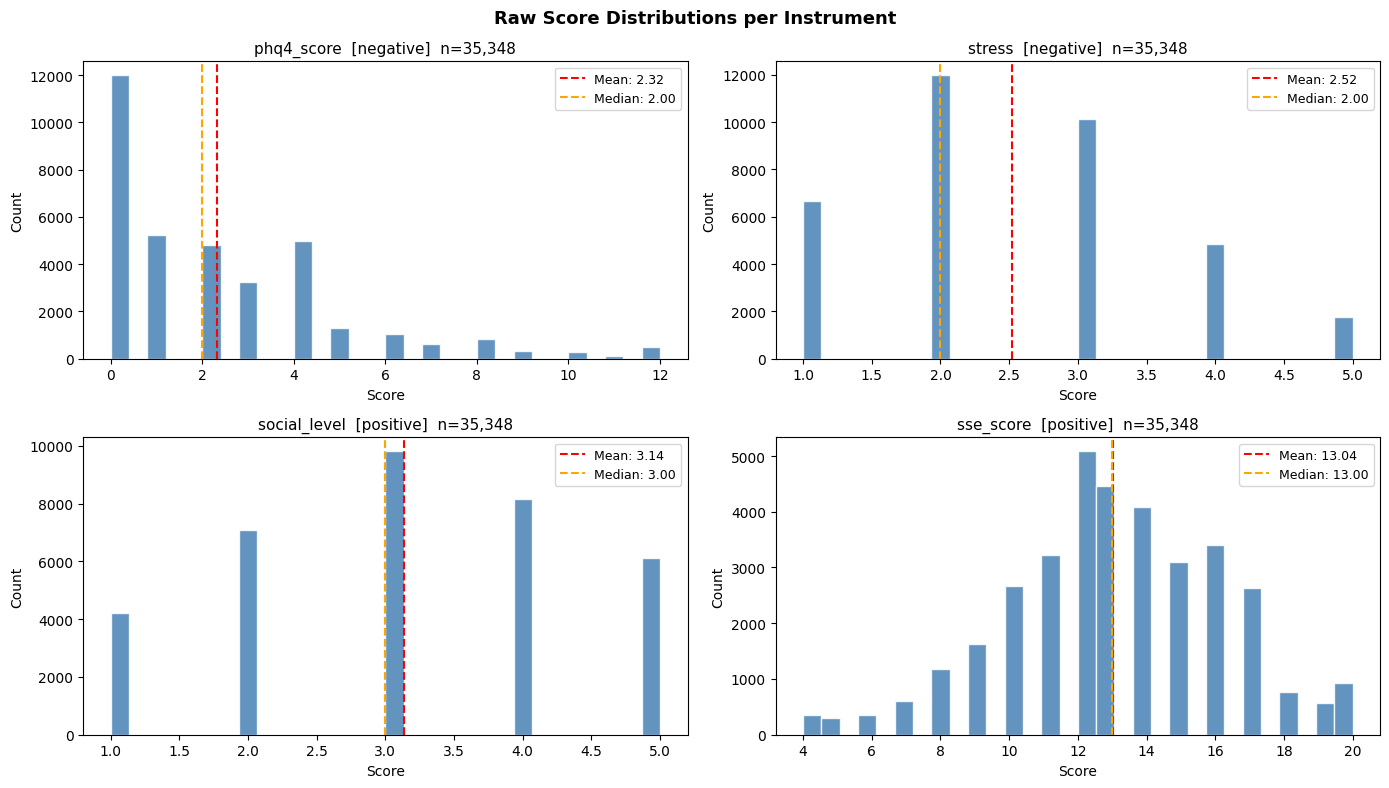


Descriptive statistics:
       phq4_score     stress  social_level  sse_score
count   35348.000  35348.000     35348.000  35348.000
mean        2.316      2.520         3.139     13.038
std         2.621      1.095         1.257      3.186
min         0.000      1.000         1.000      4.000
25%         0.000      2.000         2.000     11.000
50%         2.000      2.000         3.000     13.000
75%         4.000      3.000         4.000     15.000
max        12.000      5.000         5.000     20.000


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, meta) in enumerate(TARGET_INSTRUMENTS.items()):
    data = df[col].dropna()
    ax = axes[i]
    
    ax.hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {data.mean():.2f}")
    ax.axvline(data.median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median: {data.median():.2f}")
    
    ax.set_title(f"{col}  [{meta['direction']}]  n={len(data):,}", fontsize=11)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Raw Score Distributions per Instrument", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/general_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDescriptive statistics:")
print(df[list(TARGET_INSTRUMENTS.keys())].describe().round(3))

### Item-Level Consistency (Cronbach's Alpha)

PHQ4 and SSE are both **multi-item scales** and items are summed into a score. This is only valid if the items actually measure the same underlying construct. 

Cronbach's alpha indicates whether the items are correlated, values above 0.7 are acceptable, above 0.8 are good.

If PHQ4 or SSE alpha < 0.7 summing items is questionable.

In [28]:
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    df_clean = df_items.dropna()
    n_items = df_clean.shape[1]
    if n_items < 2 or len(df_clean) == 0:
        return float("nan")
    item_variances = df_clean.var(axis=0, ddof=1).sum()
    total_variance = df_clean.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return float("nan")
    alpha = (n_items / (n_items - 1)) * (1 - item_variances / total_variance)
    return round(alpha, 4)

# Original alpha 
alpha_phq4 = cronbach_alpha(df[PHQ4_ITEMS])
alpha_sse_original  = cronbach_alpha(df[SSE3_ITEMS])

# Reversed alpha 
sse3_items_reversed = df[SSE3_ITEMS].copy()
sse3_items_reversed["sse3-1"] = 6 - sse3_items_reversed["sse3-1"]
alpha_sse_reversed = cronbach_alpha(sse3_items_reversed)

print("Cronbach's Alpha Results")
print("=" * 40)
print(f"  PHQ4 items (phq4-1 to phq4-4)    : {alpha_phq4}  -> GOOD")
print(f"  SSE3 items - original             : {alpha_sse_original}  -> WARNING (below 0.7)")
print(f"  SSE3 items - sse3-1 reverse coded : {alpha_sse_reversed}  -> GOOD")
print()
print("Decision: sse3-1 reverse coded (6 - score) and included in SSE sum.")
print("          sse_score in df already uses the reversed item.")

print("\nPHQ4 inter-item correlation matrix:")
print(df[PHQ4_ITEMS].corr().round(3))
print("\nSSE3 inter-item correlations (sse3-1 reversed):")
print(sse3_items_reversed.corr().round(3))

Cronbach's Alpha Results
  PHQ4 items (phq4-1 to phq4-4)    : 0.8841  -> GOOD
  SSE3 items - original             : 0.4602  -> WARNING (below 0.7)
  SSE3 items - sse3-1 reverse coded : 0.7982  -> GOOD

Decision: sse3-1 reverse coded (6 - score) and included in SSE sum.
          sse_score in df already uses the reversed item.

PHQ4 inter-item correlation matrix:
        phq4-1  phq4-2  phq4-3  phq4-4
phq4-1   1.000   0.748   0.559   0.598
phq4-2   0.748   1.000   0.622   0.653
phq4-3   0.559   0.622   1.000   0.755
phq4-4   0.598   0.653   0.755   1.000

SSE3 inter-item correlations (sse3-1 reversed):
        sse3-1  sse3-2  sse3-3  sse3-4
sse3-1   1.000   0.277   0.282   0.388
sse3-2   0.277   1.000   0.644   0.696
sse3-3   0.282   0.644   1.000   0.730
sse3-4   0.388   0.696   0.730   1.000


### Cross-Instrument Correlations

How the four instruments relate to each other across all responses.

- High correlation (>0.8) between two instruments: they measure the same thing, so combining them equally will double-weight that construct
- Near-zero correlation: instruments are independent, equal weighting may be fine
- Negative correlation between a positive and negative indicator: expected and healthy

This shows if the differential weighting is needed in the composite formula.

Produces a cross instrument correlation diagram in output/figures.

Cross-instrument correlation matrix:
              phq4_score  stress  social_level  sse_score
phq4_score         1.000   0.479        -0.067     -0.527
stress             0.479   1.000        -0.104     -0.487
social_level      -0.067  -0.104         1.000      0.110
sse_score         -0.527  -0.487         0.110      1.000


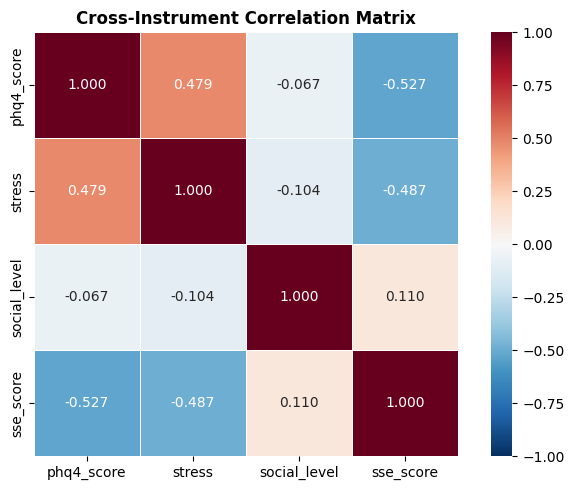

In [29]:
target_cols = list(TARGET_INSTRUMENTS.keys())
corr_matrix = df[target_cols].corr().round(3)

print("Cross-instrument correlation matrix:")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # show lower triangle only

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
)
ax.set_title("Cross-Instrument Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/general_cross_instrument_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### Per-Student Score Variance Over Time

For a predictive model to learn from a student's data, their scores must change over time in order to provide learning signal.

Each student's **standard deviation** per instrument across all their responses is computed.

Produces a variance diagram in output/figures.

Total students: 220

Variance summary across students:
       std_phq4_score  std_stress  std_social_level  std_sse_score
count         217.000     217.000           217.000        217.000
mean            1.732       0.946             1.140          2.003
std             0.764       0.196             0.201          0.552
min             0.229       0.317             0.588          0.651
25%             1.183       0.818             0.996          1.606
50%             1.689       0.954             1.160          1.961
75%             2.168       1.063             1.288          2.333
max             3.899       1.486             1.548          3.832

Students with mean std < 0.5 (low signal): 0


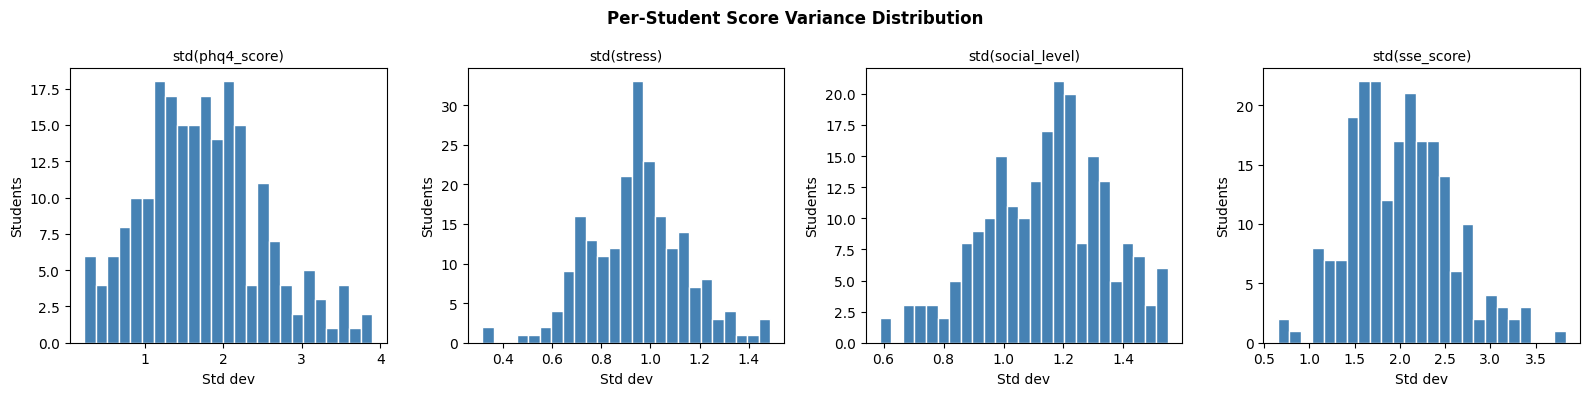

In [30]:
student_variance = (
    df.groupby("uid")[target_cols]
    .std()
    .round(3)
    .reset_index()
)
student_variance.columns = ["uid"] + [f"std_{c}" for c in target_cols]
student_variance["mean_std"] = student_variance[[f"std_{c}" for c in target_cols]].mean(axis=1)

print(f"Total students: {len(student_variance)}")
print(f"\nVariance summary across students:")
print(student_variance[[f"std_{c}" for c in target_cols]].describe().round(3))

# Flag low-variance students 
low_variance = student_variance[student_variance["mean_std"] < 0.5]
print(f"\nStudents with mean std < 0.5 (low signal): {len(low_variance)}")
if not low_variance.empty:
    print(low_variance.to_string(index=False))

# Distribution of per-student std for each instrument
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(target_cols):
    axes[i].hist(student_variance[f"std_{col}"].dropna(), bins=25, color="steelblue", edgecolor="white")
    axes[i].set_title(f"std({col})", fontsize=10)
    axes[i].set_xlabel("Std dev")
    axes[i].set_ylabel("Students")

plt.suptitle("Per-Student Score Variance Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/general_per_student_variance.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Row classification into 3 categories:
# 1. Completed survey- student filled in EMA questions (has_response = True)
# 2. Issued but not completed- app recorded timing data but student did not respond
# 3. No survey issued- entirely blank day row

RESPONSE_COLS = PHQ4_ITEMS + SSE3_ITEMS + ["phq4_score", "stress", "social_level"]
TIMING_ONLY   = ["avg_ema_spent_time"]

df["has_response"] = df[RESPONSE_COLS].notna().any(axis=1)
df["was_issued"]   = df[TIMING_ONLY].notna().any(axis=1)
df["incomplete"]   = df["was_issued"] & ~df["has_response"]
df["no_survey"]    = ~df["was_issued"] & ~df["has_response"]

print("Row classification across full dataset (220 students):")
print(f"  Completed surveys        : {df['has_response'].sum():,}")
print(f"  Issued but not completed : {df['incomplete'].sum():,}")
print(f"  No survey issued         : {df['no_survey'].sum():,}")
print(f"  Total rows               : {len(df):,}")

Row classification across full dataset (220 students):
  Completed surveys        : 35,348
  Issued but not completed : 3,659
  No survey issued         : 178,148
  Total rows               : 217,155


In [33]:
EXCLUDE_UIDS = [
    "df5e798581def8d477316520953b9171",  # 0 surveys - paper exclusion 
    "e6d71fe4a3c10b075ae1cf51a2fe6cfd",  # 0 surveys - paper exclusion 
    "ea716dd032aaa0dcf8bfa36b1811917f",  # 9 surveys, 50 days - early dropout, not in demographics
    "ad15fc229da933fbf1fc0f92fc9b55a3",  # 1 survey, 2 days - withdrawal
]

df_clean = df[~df["uid"].isin(EXCLUDE_UIDS)].copy()

print(f"Students before exclusion : {df['uid'].nunique()}")
print(f"Students after exclusion  : {df_clean['uid'].nunique()}")
print(f"Rows before exclusion     : {len(df):,}")
print(f"Rows after exclusion      : {len(df_clean):,}")

Students before exclusion : 220
Students after exclusion  : 216
Rows before exclusion     : 217,155
Rows after exclusion      : 217,097


---
## Label Definition Feasibility

The model requires exactly one label per `(uid, year_week)`.
Since surveys arrive irregularly, some weeks have multiple responses and some have none.

This section determines:
- How often multiple surveys occur in the same week, driving the aggregation rule choice
- How much scores vary within the same week, validating the chosen aggregation rule
- How many weeks are completely missing per student, driving the imputation strategy
- Whether a composite score simulation produces a meaningful spread across 0-100%

All analysis uses `df_clean` - 216 students after excluding anomalous UIDs.
Only rows where `has_response == True` are counted as valid survey responses.

### Survey Count Distribution Per Week

How many surveys does a student complete within a single ISO week?
If most weeks have exactly 1 survey, aggregation to a weekly label is trivial.
If many weeks have 2 or more, a justified aggregation rule is required.

In [34]:
# Use only completed survey rows from the clean dataset
df_b = df_clean[df_clean["has_response"]].copy()

weekly = (
    df_b.groupby(["uid", "year_week"])
    .size()
    .reset_index(name="surveys_in_week")
)

dist = (
    weekly["surveys_in_week"]
    .value_counts()
    .sort_index()
    .reset_index()
)
dist.columns = ["surveys_in_week", "n_student_weeks"]
dist["pct"] = (dist["n_student_weeks"] / dist["n_student_weeks"].sum() * 100).round(2)

print("Survey count distribution per (student, week):")
print(dist.to_string(index=False))
print(f"\nTotal (student, week) pairs with at least 1 survey : {len(weekly):,}")
print(f"Mean surveys per (student, week)                   : {weekly['surveys_in_week'].mean():.2f}")

single = dist[dist["surveys_in_week"] == 1]["pct"].values[0]
multi  = dist[dist["surveys_in_week"] > 1]["n_student_weeks"].sum()
print(f"\nWeeks with exactly 1 survey : {single:.1f}%")
print(f"Weeks with 2+ surveys       : {multi:,} ({multi/len(weekly)*100:.1f}%)")

Survey count distribution per (student, week):
 surveys_in_week  n_student_weeks   pct
               1            15838 64.92
               2             6440 26.40
               3             1867  7.65
               4              242  0.99
               5                9  0.04
               6                1  0.00

Total (student, week) pairs with at least 1 survey : 24,397
Mean surveys per (student, week)                   : 1.45

Weeks with exactly 1 survey : 64.9%
Weeks with 2+ surveys       : 8,559 (35.1%)


### Intra-Week Score Variance

For weeks where a student submitted multiple surveys, how much do their scores
vary within that same week?

- Low intra-week variance validates using the mean as the weekly label
- High intra-week variance means the mean may hide real within-week swings,
  and an alternative rule (last response, worst-case) should be considered

In [35]:
target_cols = list(TARGET_INSTRUMENTS.keys())

# Isolate weeks with 2+ surveys
multi_weeks = weekly[weekly["surveys_in_week"] > 1][["uid", "year_week"]]
df_multi    = df_b.merge(multi_weeks, on=["uid", "year_week"])

intra_std = (
    df_multi.groupby(["uid", "year_week"])[target_cols]
    .std()
    .reset_index()
)

print(f"(student, week) pairs with 2+ surveys: {len(multi_weeks):,}")
print(f"\nIntra-week score std - summary across those pairs:")
print(intra_std[target_cols].describe().round(3))

# Flag weeks with high intra-week variance per instrument
thresholds = {"phq4_score": 2.0, "stress": 1.5, "social_level": 1.5, "sse_score": 2.0}
print("\nHigh intra-week variance flags:")
for col, thresh in thresholds.items():
    n = (intra_std[col] > thresh).sum()
    pct = n / max(len(intra_std), 1) * 100
    print(f"  {col} std > {thresh}: {n} weeks ({pct:.1f}% of multi-survey weeks)")

(student, week) pairs with 2+ surveys: 8,559

Intra-week score std - summary across those pairs:
       phq4_score    stress  social_level  sse_score
count    8559.000  8559.000      8559.000   8559.000
mean        0.604     0.511         0.750      1.130
std         0.834     0.520         0.688      1.085
min         0.000     0.000         0.000      0.000
25%         0.000     0.000         0.000      0.577
50%         0.000     0.577         0.707      0.707
75%         0.707     0.707         1.414      1.528
max         8.485     2.828         2.828     10.607

High intra-week variance flags:
  phq4_score std > 2.0: 700 weeks (8.2% of multi-survey weeks)
  stress std > 1.5: 253 weeks (3.0% of multi-survey weeks)
  social_level std > 1.5: 931 weeks (10.9% of multi-survey weeks)
  sse_score std > 2.0: 1737 weeks (20.3% of multi-survey weeks)


### Observation Gaps

Between a student's first and last survey date, how many ISO weeks contain
no completed survey responses?

These gaps are weeks where no label can be directly computed. 

In [36]:
def compute_gap_weeks(df: pd.DataFrame) -> pd.DataFrame:
    completed = df[df["has_response"]]
    observed_weeks = completed.groupby("uid")["year_week"].apply(set)
    date_range     = completed.groupby("uid")["date"].agg(start="min", end="max")

    results = []
    for uid, row in date_range.iterrows():
        all_dates  = pd.date_range(row["start"], row["end"], freq="W-MON")
        all_weeks  = set(
            str(d.isocalendar()[0]) + "-W" + str(d.isocalendar()[1]).zfill(2)
            for d in all_dates
        )
        observed   = observed_weeks.get(uid, set())
        gap_weeks  = len(all_weeks - observed)
        total_weeks = len(all_weeks)
        results.append({
            "uid":                uid,
            "total_weeks_in_span": total_weeks,
            "observed_weeks":     len(observed),
            "gap_weeks":          gap_weeks,
            "pct_gap":            round(gap_weeks / max(total_weeks, 1) * 100, 2),
        })

    return pd.DataFrame(results).sort_values("pct_gap", ascending=False).reset_index(drop=True)


gaps = compute_gap_weeks(df_clean)

print("Gap week summary across 217 students:")
print(gaps[["total_weeks_in_span", "observed_weeks", "gap_weeks", "pct_gap"]].describe().round(2))

high_gap = gaps[gaps["pct_gap"] > 50]
print(f"\nStudents with more than 50% gap weeks : {len(high_gap)}")
print(f"Median gap rate across all students   : {gaps['pct_gap'].median():.1f}%")
print(f"Mean gap rate across all students     : {gaps['pct_gap'].mean():.1f}%")

# Also check surveys issued but not completed
incomplete_per_student = (
    df_clean[df_clean["incomplete"]]
    .groupby("uid")
    .size()
    .reset_index(name="incomplete_surveys")
)
print(f"\nStudents with at least one incomplete survey : {len(incomplete_per_student)}")
print(f"Total incomplete survey rows                 : {df_clean['incomplete'].sum():,}")

Gap week summary across 217 students:
       total_weeks_in_span  observed_weeks  gap_weeks  pct_gap
count               216.00          216.00     216.00   216.00
mean                153.99          112.95      41.97    28.84
std                  52.31           49.83      25.57    17.11
min                   9.00            7.00       0.00     0.00
25%                 130.75           74.50      23.00    14.81
50%                 180.00          126.00      38.00    25.82
75%                 190.00          155.00      59.25    38.90
max                 205.00          184.00     118.00    80.85

Students with more than 50% gap weeks : 29
Median gap rate across all students   : 25.8%
Mean gap rate across all students     : 28.8%

Students with at least one incomplete survey : 161
Total incomplete survey rows                 : 3,659


### Composite Score Simulation

A try run of the composite formula using equal weights and min-max normalization.

Formula applied:
1. Normalize each instrument to [0, 1] using its valid range
2. Invert negative indicators (PHQ4, stress): normalized = 1 - normalized
3. Average the four normalized scores with equal weights
4. Multiply by 100 to express as a percentage

SSE uses sse3-1 reverse coded. All four instruments included.

Produces a composite score distribution diagram in output/figures.

Composite score simulation (equal weights, min-max normalization)
Rows with all 4 instruments present : 35,338 / 35,338

Distribution:
count    35338.00
mean        63.16
std         16.92
min          0.00
25%         52.60
50%         64.06
75%         75.00
max        100.00
Name: composite_score, dtype: float64


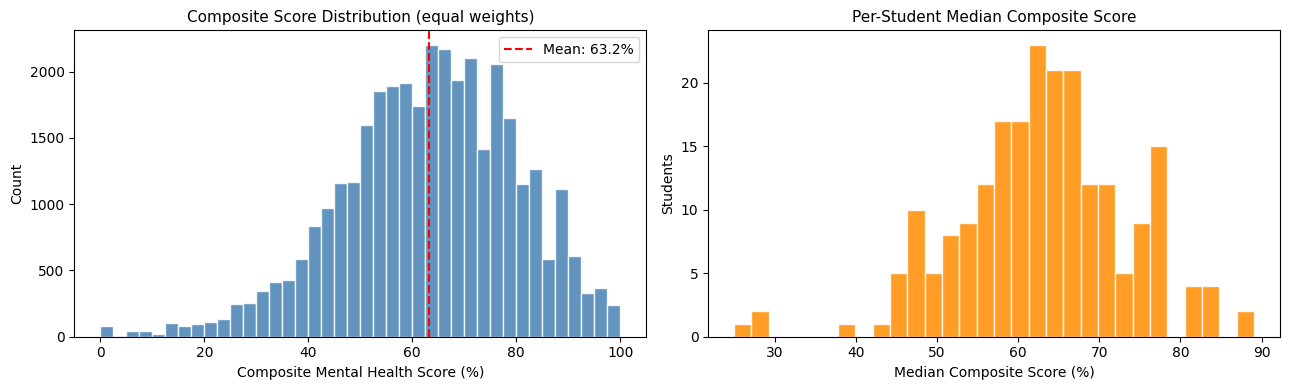


Rows excluded from composite (at least one instrument missing): 0


In [37]:
def normalize_instrument(series, min_val, max_val, invert):
    normalized = (series - min_val) / (max_val - min_val)
    normalized = normalized.clip(0, 1)
    if invert:
        normalized = 1 - normalized
    return normalized

ranges = {
    "phq4_score":   (0,  12, True),
    "stress":       (1,  5,  True),
    "social_level": (1,  5,  False),
    "sse_score":    (4,  20, False),
}

df_sim   = df_clean[df_clean["has_response"]].copy()
norm_cols = []

for col, (mn, mx, inv) in ranges.items():
    nc = f"norm_{col}"
    df_sim[nc] = normalize_instrument(df_sim[col], mn, mx, inv)
    norm_cols.append(nc)

df_sim["composite_score"] = df_sim[norm_cols].mean(axis=1, skipna=False) * 100

valid = df_sim["composite_score"].dropna()
print("Composite score simulation (equal weights, min-max normalization)")
print(f"Rows with all 4 instruments present : {len(valid):,} / {len(df_sim):,}")
print(f"\nDistribution:")
print(valid.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(valid, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(valid.mean(), color="red", linestyle="--",
                label=f"Mean: {valid.mean():.1f}%")
axes[0].set_title("Composite Score Distribution (equal weights)", fontsize=11)
axes[0].set_xlabel("Composite Mental Health Score (%)")
axes[0].set_ylabel("Count")
axes[0].legend()

student_median = df_sim.groupby("uid")["composite_score"].median().dropna().sort_values()
axes[1].hist(student_median, bins=30, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_title("Per-Student Median Composite Score", fontsize=11)
axes[1].set_xlabel("Median Composite Score (%)")
axes[1].set_ylabel("Students")

plt.tight_layout()
plt.savefig("../../outputs/figures/general_composite_score_simulation.png",
            dpi=150, bbox_inches="tight")
plt.show()

partial = df_sim[norm_cols].isna().any(axis=1).sum()
print(f"\nRows excluded from composite (at least one instrument missing): {partial:,}")